In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
print("Libraries loaded successfully")

Libraries loaded successfully


In [24]:
df = pd.read_csv(r"C:\Users\Diksha\PlacifyX\data\raw\placementdata.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (10000, 12)

Columns: ['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [25]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB
None

=== Missing Value

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


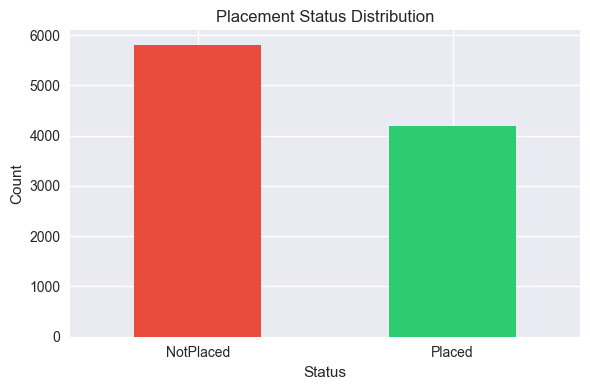

PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

Placement Rate: 41.97%


In [26]:
plt.figure(figsize=(6,4))
colors = ['#2ecc71' if x == 'Placed' else '#e74c3c' 
          for x in df['PlacementStatus'].value_counts().index]
df['PlacementStatus'].value_counts().plot(kind='bar', color=colors)
plt.title('Placement Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df['PlacementStatus'].value_counts())
print(f"\nPlacement Rate: {round(df['PlacementStatus'].value_counts()['Placed']/len(df)*100, 2)}%")

## Placement Distribution
- 4197 placed (41.97%), 5803 not placed (58.03%)
- Dataset is imbalanced - will handle with class balancing during modeling

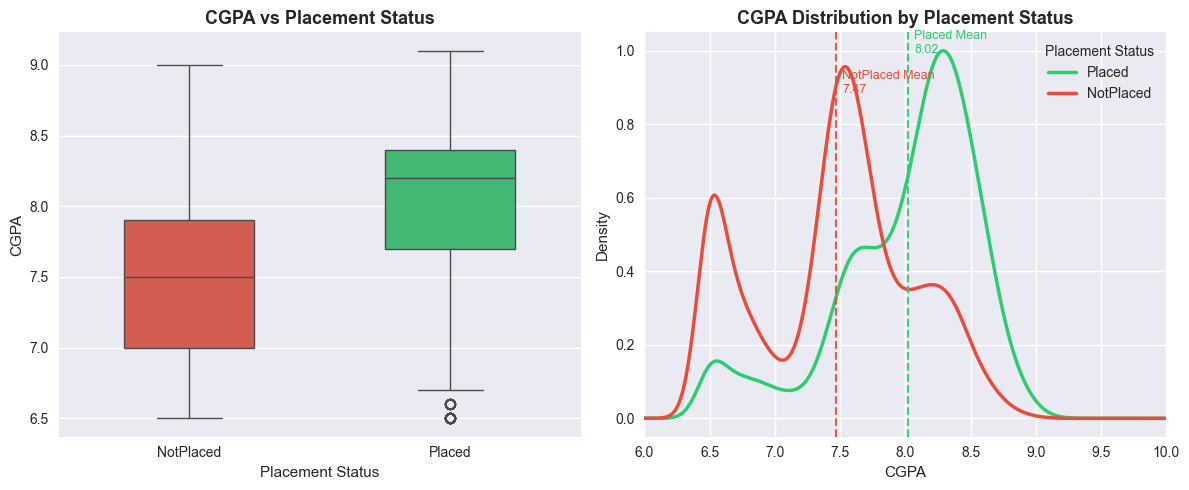

                  count      mean       std  min  25%  50%  75%  max
PlacementStatus                                                     
NotPlaced        5803.0  7.467672  0.602653  6.5  7.0  7.5  7.9  9.0
Placed           4197.0  8.016488  0.547213  6.5  7.7  8.2  8.4  9.1


In [31]:
palette = {'Placed': '#2ecc71', 'NotPlaced': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='PlacementStatus', y='CGPA', data=df, palette=palette,
            order=['NotPlaced', 'Placed'], ax=axes[0], width=0.5)
axes[0].set_title('CGPA vs Placement Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Placement Status')
axes[0].set_ylabel('CGPA')

# KDE plot
for status, color in palette.items():
    subset = df[df['PlacementStatus'] == status]['CGPA']
    subset.plot.kde(ax=axes[1], color=color, linewidth=2.5, label=status)

# Mean lines with labels
placed_mean = df[df['PlacementStatus']=='Placed']['CGPA'].mean()
notplaced_mean = df[df['PlacementStatus']=='NotPlaced']['CGPA'].mean()

axes[1].axvline(placed_mean, color='#2ecc71', linestyle='--', alpha=0.9, linewidth=1.5)
axes[1].axvline(notplaced_mean, color='#e74c3c', linestyle='--', alpha=0.9, linewidth=1.5)

axes[1].text(placed_mean + 0.05, 0.95, f'Placed Mean\n{placed_mean:.2f}',
             color='#2ecc71', fontsize=9, transform=axes[1].get_xaxis_transform())
axes[1].text(notplaced_mean + 0.05, 0.85, f'NotPlaced Mean\n{notplaced_mean:.2f}',
             color='#e74c3c', fontsize=9, transform=axes[1].get_xaxis_transform())

axes[1].set_title('CGPA Distribution by Placement Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('CGPA')
axes[1].set_ylabel('Density')
axes[1].legend(title='Placement Status')
axes[1].set_xlim(6, 10)

plt.tight_layout()
plt.show()

print(df.groupby('PlacementStatus')['CGPA'].describe())

## CGPA vs Placement
- Placed mean CGPA: 8.02, NotPlaced mean CGPA: 7.47
- 0.55 CGPA gap - higher CGPA strongly predicts placement

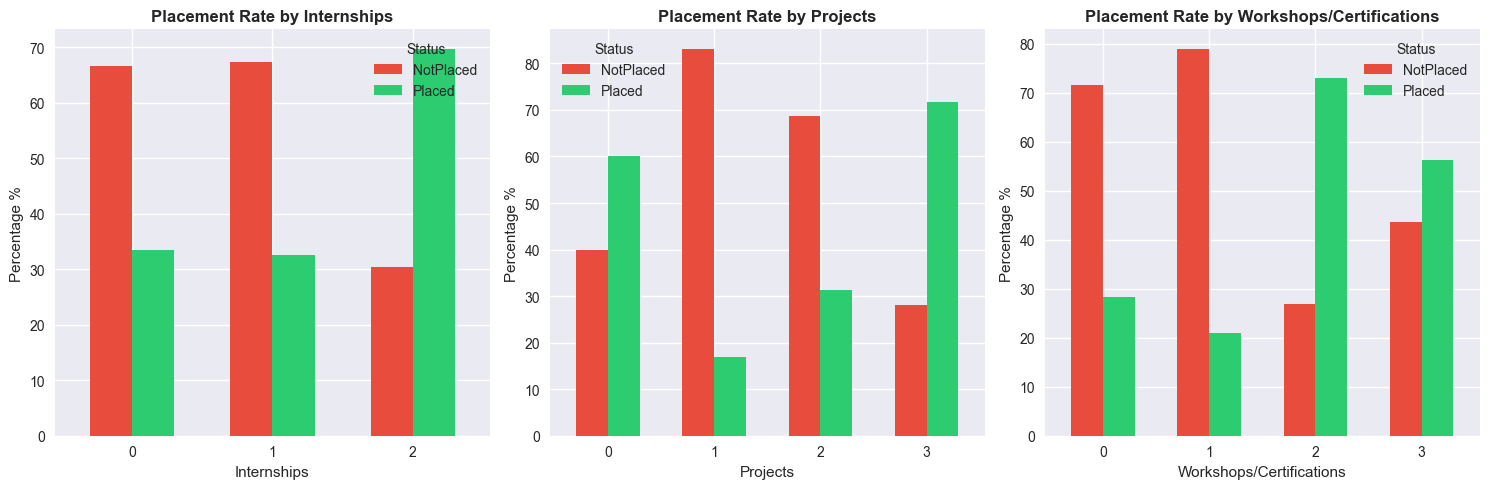

Internships:
 PlacementStatus  NotPlaced     Placed
Internships                          
0                66.565809  33.434191
1                67.358354  32.641646
2                30.303030  69.696970

Projects:
 PlacementStatus  NotPlaced     Placed
Projects                             
0                40.000000  60.000000
1                83.140682  16.859318
2                68.627451  31.372549
3                28.195198  71.804802

Workshops:
 PlacementStatus           NotPlaced     Placed
Workshops/Certifications                      
0                         71.623429  28.376571
1                         78.945400  21.054600
2                         26.945201  73.054799
3                         43.661972  56.338028


In [32]:
palette = {'Placed': '#2ecc71', 'NotPlaced': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Internships', 'Projects', 'Workshops/Certifications']):
    ct = df.groupby(col)['PlacementStatus'].value_counts(normalize=True).unstack()*100
    ct[['NotPlaced', 'Placed']].plot(kind='bar', color=['#e74c3c', '#2ecc71'], 
                                      ax=ax, width=0.6)
    ax.set_title(f'Placement Rate by {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage %')
    ax.legend(title='Status')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Internships:\n", df.groupby('Internships')['PlacementStatus'].value_counts(normalize=True).unstack()*100)
print("\nProjects:\n", df.groupby('Projects')['PlacementStatus'].value_counts(normalize=True).unstack()*100)
print("\nWorkshops:\n", df.groupby('Workshops/Certifications')['PlacementStatus'].value_counts(normalize=True).unstack()*100)

## Internships, Projects, Workshops vs Placement
- 2 internships: 69.7% placed vs 1 internship: 32.6% - quality over quantity
- 3 projects: 71.8% placed vs 1 project: only 16.9%
- Non-linear pattern: doing "some" barely helps, doing "enough" makes a big difference

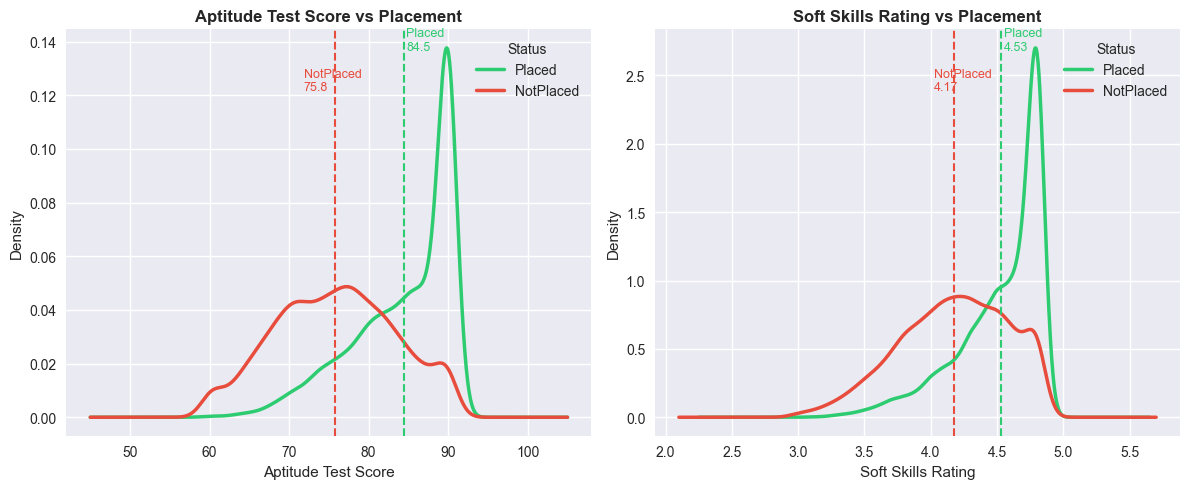

Aptitude Score:
                   count       mean       std   min   25%   50%   75%   max
PlacementStatus                                                           
NotPlaced        5803.0  75.829399  7.482936  60.0  70.0  76.0  81.0  90.0
Placed           4197.0  84.455802  6.168724  60.0  81.0  86.0  90.0  90.0

Soft Skills:
                   count      mean       std  min  25%  50%  75%  max
PlacementStatus                                                     
NotPlaced        5803.0  4.174393  0.407034  3.0  3.9  4.2  4.5  4.8
Placed           4197.0  4.530760  0.317731  3.1  4.4  4.6  4.8  4.8


In [38]:
palette = {'Placed': '#2ecc71', 'NotPlaced': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Aptitude Test Score
for status, color in palette.items():
    subset = df[df['PlacementStatus'] == status]['AptitudeTestScore']
    subset.plot.kde(ax=axes[0], color=color, linewidth=2.5, label=status)

aptitude_placed = df[df['PlacementStatus']=='Placed']['AptitudeTestScore'].mean()
aptitude_notplaced = df[df['PlacementStatus']=='NotPlaced']['AptitudeTestScore'].mean()

axes[0].axvline(aptitude_placed, color='#2ecc71', linestyle='--', linewidth=1.5)
axes[0].axvline(aptitude_notplaced, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[0].text(aptitude_placed+0.3, 0.95, f'Placed\n{aptitude_placed:.1f}',
             color='#2ecc71', fontsize=9, transform=axes[0].get_xaxis_transform())
axes[0].text(aptitude_notplaced-4, 0.85, f'NotPlaced\n{aptitude_notplaced:.1f}',
             color='#e74c3c', fontsize=9, transform=axes[0].get_xaxis_transform())
axes[0].set_title('Aptitude Test Score vs Placement', fontweight='bold')
axes[0].set_xlabel('Aptitude Test Score')
axes[0].set_ylabel('Density')
axes[0].legend(title='Status')

# Soft Skills Rating
for status, color in palette.items():
    subset = df[df['PlacementStatus'] == status]['SoftSkillsRating']
    subset.plot.kde(ax=axes[1], color=color, linewidth=2.5, label=status)

soft_placed = df[df['PlacementStatus']=='Placed']['SoftSkillsRating'].mean()
soft_notplaced = df[df['PlacementStatus']=='NotPlaced']['SoftSkillsRating'].mean()

axes[1].axvline(soft_placed, color='#2ecc71', linestyle='--', linewidth=1.5)
axes[1].axvline(soft_notplaced, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[1].text(soft_placed+0.02, 0.95, f'Placed\n{soft_placed:.2f}',
             color='#2ecc71', fontsize=9, transform=axes[1].get_xaxis_transform())
axes[1].text(soft_notplaced-0.15, 0.85, f'NotPlaced\n{soft_notplaced:.2f}',
             color='#e74c3c', fontsize=9, transform=axes[1].get_xaxis_transform())
axes[1].set_title('Soft Skills Rating vs Placement', fontweight='bold')
axes[1].set_xlabel('Soft Skills Rating')
axes[1].set_ylabel('Density')
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()

print("Aptitude Score:\n", df.groupby('PlacementStatus')['AptitudeTestScore'].describe())
print("\nSoft Skills:\n", df.groupby('PlacementStatus')['SoftSkillsRating'].describe())

## Aptitude Score & Soft Skills vs Placement
- Aptitude: Placed mean 84.5 vs NotPlaced 75.8 - 8.7 point gap, strong predictor
- Soft Skills: Placed mean 4.53 vs NotPlaced 4.17 - moderate predictor

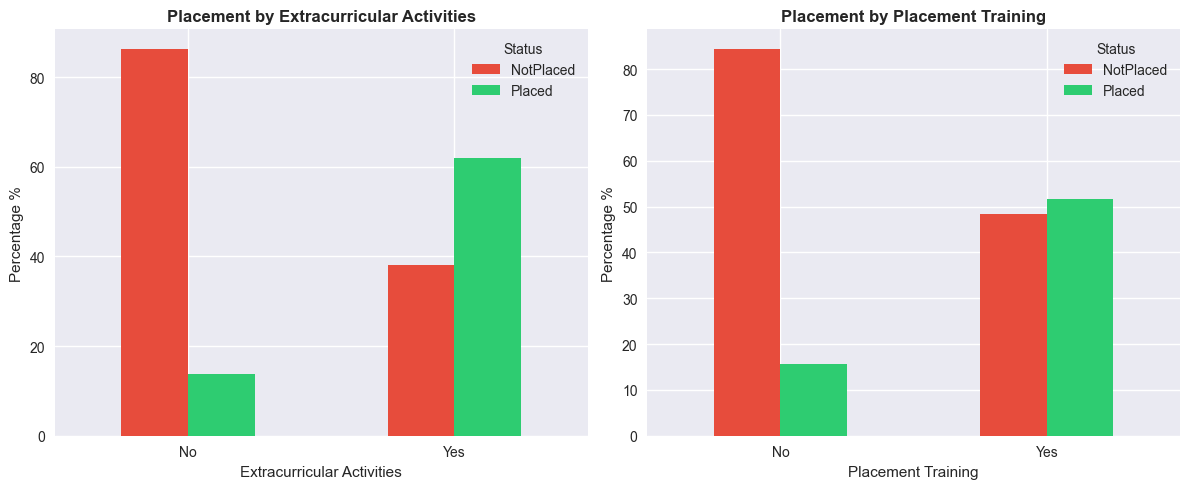

Extracurricular:
 PlacementStatus            NotPlaced     Placed
ExtracurricularActivities                      
No                         86.324168  13.675832
Yes                        37.991117  62.008883

Placement Training:
 PlacementStatus    NotPlaced     Placed
PlacementTraining                      
No                 84.414616  15.585384
Yes                48.360208  51.639792


In [39]:
palette = {'Placed': '#2ecc71', 'NotPlaced': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Extracurricular Activities
extra = df.groupby('ExtracurricularActivities')['PlacementStatus'].value_counts(normalize=True).unstack()*100
extra[['NotPlaced','Placed']].plot(kind='bar', color=['#e74c3c','#2ecc71'], 
                                    ax=axes[0], width=0.5)
axes[0].set_title('Placement by Extracurricular Activities', fontweight='bold')
axes[0].set_xlabel('Extracurricular Activities')
axes[0].set_ylabel('Percentage %')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Status')

# Placement Training
training = df.groupby('PlacementTraining')['PlacementStatus'].value_counts(normalize=True).unstack()*100
training[['NotPlaced','Placed']].plot(kind='bar', color=['#e74c3c','#2ecc71'],
                                       ax=axes[1], width=0.5)
axes[1].set_title('Placement by Placement Training', fontweight='bold')
axes[1].set_xlabel('Placement Training')
axes[1].set_ylabel('Percentage %')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()

print("Extracurricular:\n", df.groupby('ExtracurricularActivities')['PlacementStatus'].value_counts(normalize=True).unstack()*100)
print("\nPlacement Training:\n", df.groupby('PlacementTraining')['PlacementStatus'].value_counts(normalize=True).unstack()*100)

## Extracurricular Activities & Placement Training
- Extracurriculars: 62% placed (Yes) vs 13.7% (No) - 48% gap, biggest predictor
- Placement Training: 51.6% placed (Yes) vs 15.6% (No) - 36% gap

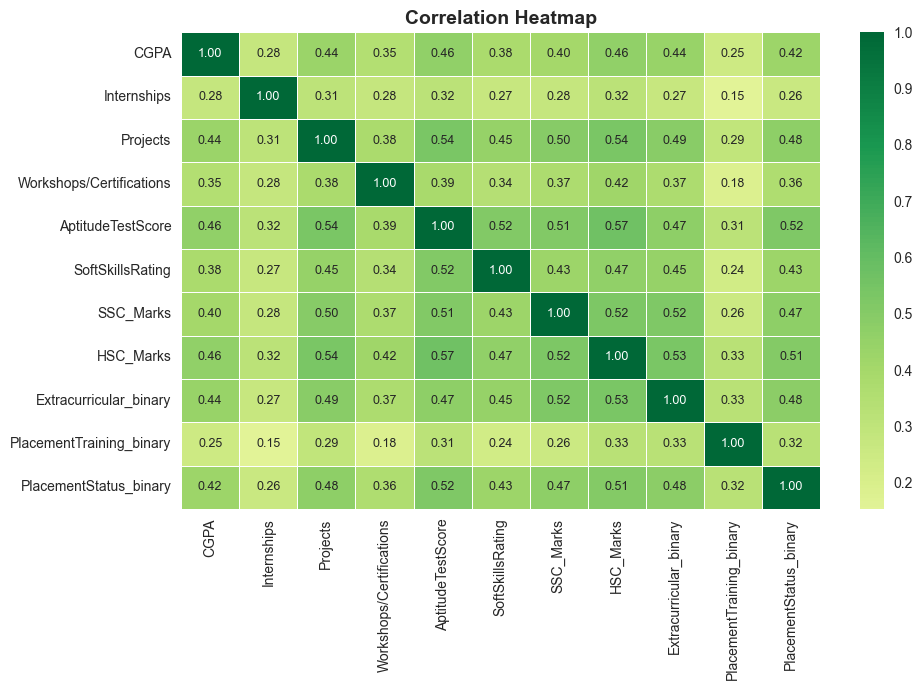

In [40]:
plt.figure(figsize=(10,7))

df_numeric = df.copy()
df_numeric['PlacementStatus_binary'] = (df['PlacementStatus'] == 'Placed').astype(int)
df_numeric['Extracurricular_binary'] = (df['ExtracurricularActivities'] == 'Yes').astype(int)
df_numeric['PlacementTraining_binary'] = (df['PlacementTraining'] == 'Yes').astype(int)

numeric_cols = ['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
                'AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks',
                'Extracurricular_binary', 'PlacementTraining_binary', 'PlacementStatus_binary']

sns.heatmap(df_numeric[numeric_cols].corr(), 
            annot=True, cmap='RdYlGn', fmt='.2f', center=0,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Heatmap
- Top predictors: AptitudeTestScore (0.52), HSC_Marks (0.51), Projects (0.48)
- Extracurricular activities stronger predictor than CGPA alone
- Internships weakest predictor (0.26) - surprising finding